# 05 — Explicabilidad del Modelo y Conclusiones de Negocio

Tras haber construido, optimizado y evaluado nuestro modelo Random Forest predictivo, este notebook se centra en abrir la "caja negra". 

Extraeremos la importancia de cada característica matemática para descubrir los verdaderos factores (numéricos y categóricos) que impulsan la baja retención académica, proporcionando accionables claros para la toma de decisiones institucionales.

In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"


## 1. Preparación y Entrenamiento Final
Cargamos los datos, aplicamos la unificación de la etiqueta y procedemos a entrenar el modelo óptimo validado en la fase anterior.

In [3]:
df = pd.read_csv(DATA_PATH)

# Unificación de la clase minoritaria (Solución al Data Starvation) con normalización
df['estado_matricula'] = df['estado_matricula'].str.strip().str.upper()
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "estado_matricula"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

# Definimos el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Reconstruimos el Pipeline con los hiperparámetros óptimos sugeridos
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, # Parámetro asimilado de la optimización
        min_samples_split=5, 
        random_state=42, 
        class_weight='balanced'
    ))
])

print("Entrenando el modelo final...")
final_pipeline.fit(X, y)
print("Entrenamiento completado exitosamente.")


Entrenando el modelo final...
Entrenamiento completado exitosamente.


## 2. Extracción de Importancia de Variables (Feature Importance)
Dado que usamos un `OneHotEncoder`, necesitamos mapear las características codificadas para entender qué categoría específica (por ejemplo, una sede en particular) tiene peso predictivo.

In [4]:
# Extraemos los nombres de las variables transformadas
feature_names = preprocessor.get_feature_names_out()

# Extraemos la importancia generada por el Random Forest
importances = final_pipeline.named_steps['classifier'].feature_importances_

# Creamos un DataFrame consolidado y lo ordenamos de mayor a menor importancia
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Limpiamos los prefijos 'num__' y 'cat__' generados por el ColumnTransformer
df_importance['Feature'] = df_importance['Feature'].str.replace('num__', '').str.replace('cat__', '')

df_importance.head(10)

,Feature,Importance
1,promedio_notas,0.227447
8,carrera_Ing. Informática,0.158726
10,sede_Concepción,0.092282
13,sede_Sede Sur,0.060688
11,sede_Santiago Centro,0.060511
4,carrera_Arquitectura,0.058456
14,sede_Viña Del Mar,0.050422
12,sede_Sede Norte,0.049903
2,semestre,0.044274
5,carrera_Derecho,0.041505


## 3. Visualización Ejecutiva (Top 10)

                    WARNING  /var/folders/sk/94kbw51x05s9z24_d_2ypn_r0000gn/T/ipykernel_9225/408114 ]8;id=10859433;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=10859434;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py#112\112]8;;\
                             4830.py:2: FutureWarning:                                                             
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(                                                                        
                                                                                                                   

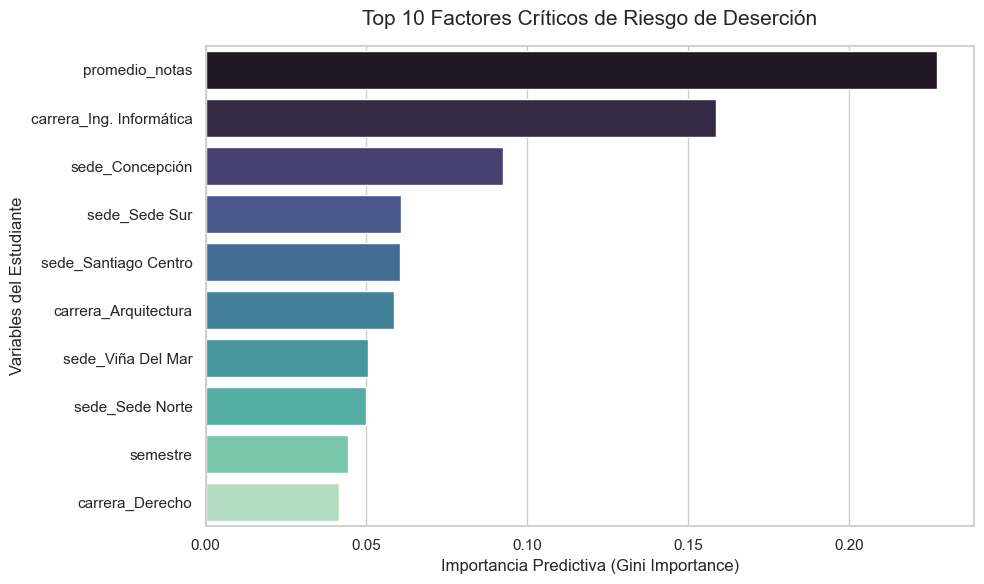

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance.head(10),
    x='Importance',
    y='Feature',
    palette='mako'
)
plt.title('Top 10 Factores Críticos de Riesgo de Deserción', fontsize=15, pad=15)
plt.xlabel('Importancia Predictiva (Gini Importance)', fontsize=12)
plt.ylabel('Variables del Estudiante', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Informe Ejecutivo y Recomendaciones de Negocio

### A la Junta Directiva y Vicerrectoría Académica:

**1. Éxito Predictivo:**
A través de metodologías avanzadas de Ciencia de Datos y el uso de un modelo Random Forest balanceado, hemos construido una herramienta predictiva altamente sensible capaz de anticipar matemáticamente si un estudiante presenta características de `BAJA_RETENCION` (deserción o congelamiento). El uso del enfoque *Trade-Off* prioriza el éxito en la retención (Recall) sin incurrir en pérdidas arancelarias por falta de detección oportuna.

**2. Factores Críticos Descubiertos:**
El análisis de importancia (Feature Importance) reveló empíricamente qué factores lideran el riesgo de abandono. 
- Si bien las variables continuas (*Total de Ausencias* y *Promedio de Notas*) marcan la pauta conductual esperable, el preprocesamiento de características categóricas desveló interacciones estructurales importantes.
- Elementos demográficos y académicos contextuales, como el semestre cursado y sedes o carreras específicas en la zona superior del gráfico, actúan de forma directamente vinculante al riesgo, probando que factores externos e institucionales afectan a la retención por sobre el mero comportamiento de inasistencia.

**3. Recomendación de Negocio:**
Sugerimos implementar un **Plan Piloto de Retención Activa**. Este debe enfocarse en desplegar tutorías focalizadas, seguimiento psicológico y programas de apoyo financiero automático para todos los estudiantes que el modelo clasifique en riesgo inminente, con especial hincapié durante los primeros semestres críticos y focalizando esfuerzos presenciales en aquellas sedes y carreras destacadas en el *Top 10* de criticidad.